In [1]:
import xarray as xr 
import numpy as np 
import matplotlib.pyplot as plt 


In [2]:
f = "../data/001_raw/ECMWF_utci_2023_prueba.nc"

utci = xr.open_dataset(f)
utci

<xarray.Dataset> Size: 249MB
Dimensions:  (time: 72, lat: 601, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 576B 2023-01-01 ... 2023-01-03T23:00:00
  * lat      (lat) float64 5kB 90.0 89.75 89.5 89.25 ... -59.5 -59.75 -60.0
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    utci     (time, lat, lon) float32 249MB ...
Attributes:
    CDI:                       Climate Data Interface version 1.9.10 (https:/...
    Conventions:               CF-1.6
    institution:               European Centre for Medium-Range Weather Forec...
    CDO:                       Climate Data Operators version 1.9.10 (https:/...
    cdo_openmp_thread_number:  8
    history:                   Wed Apr 26 11:35:18 2023: ncatted -a _FillValu...
    NCO:                       netCDF Operators version 4.9.7 (Homepage = htt...

In [3]:
def seleccionar_pais (ds, lat1, lat2, lon1, lon2):
    ds = ds.sel(lat = slice(lat1, lat2), lon= slice(lon1, lon2))

    return ds

In [4]:
def convertir_a_celsius(ds):
    ds_celsius = ds.copy()
    ds_celsius["utci"] = ds["utci"] - 273.15
    ds_celsius["utci"].attrs["units"] = "°C"
    return ds_celsius

In [5]:
mexico = seleccionar_pais(utci, 33, 14, -118, -86)
mexico = convertir_a_celsius(mexico)

In [6]:
def obtener_utci(ds, dia, hora):

    fecha_hora = f"{dia}T{hora:02d}:00:00"

    return ds.sel(time=fecha_hora)["utci"].values

In [7]:
data = obtener_utci(
    mexico,
    "2023-01-02",
    18
)

In [8]:
def graficar_utci(ds, dia, hora):

    fecha_hora = f"{dia}T{hora:02d}:00:00"

    data = ds.sel(time=fecha_hora)["utci"].values

    plt.figure(figsize=(10,6))

    plt.imshow(
        data,
        extent=[
            float(ds.lon.min()),
            float(ds.lon.max()),
            float(ds.lat.min()),
            float(ds.lat.max())
        ],
        origin="upper",
        cmap="RdYlGn_r",
        vmin=0,
        vmax=46
    )

    plt.colorbar(label="UTCI (°C)")
    plt.title(f"UTCI México - {dia} {hora:02d}:00 UTC")
    plt.xlabel("Longitud")
    plt.ylabel("Latitud")

    plt.show()

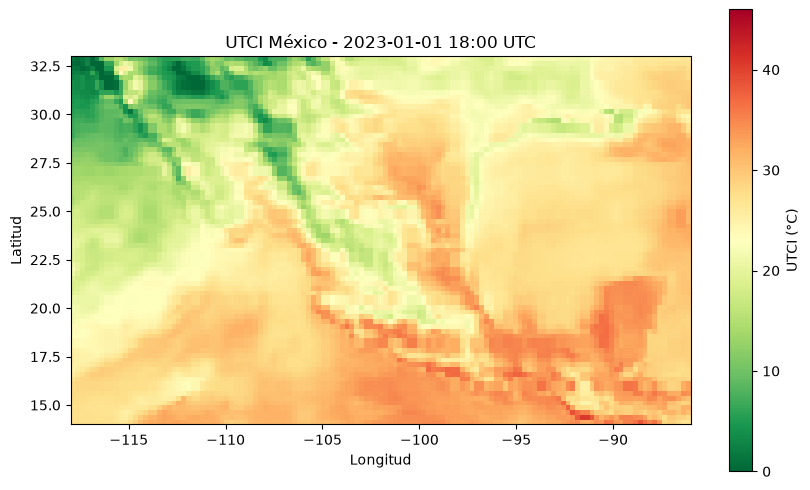

In [9]:
graficar_utci(
    mexico,
    "2023-01-01",
    18
)